# Beat Timer v0.4

An audio-only tempo and timing-section notebook with optional `.osu` evaluation.

The predictor reads only the MP3. When an `.osu` file is supplied, its hit objects and red timing points are used strictly as an external scorecard. v0.4 removes the experimental scratch cells from v0.3.1 and consolidates analysis, visualization, and evaluation into named functions.

## Workflow

1. Configure the MP3 and optional `.osu` paths.
2. Run the audio-only analysis.
3. Inspect the interactive timing plot.
4. Optionally evaluate object-grid errors, diagnostic phase bias, and redline agreement.

The diagnostic phase shift is reported separately and never written back into the audio prediction.

In [1]:
from copy import deepcopy
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from IPython.display import display
from plotly.subplots import make_subplots

## Configuration

In [ ]:
# Required input.
AUDIO_PATH = Path("sakuzyo_that_day.mp3")

# Optional evaluation input. The .osu file is never used for prediction.
OSU_PATH = Path("sakuzyo_that_day.osu")
RUN_OSU_EVALUATION = True

# Audio analysis.
N_FFT = 2048
HOP_LENGTH = 256

# Global BPM search range.
MIN_BPM = 60
MAX_BPM = 240

# BPM rounding:
# 0 = integer, 1 = one decimal, n = n decimals, None = no rounding.
ROUND_INITIAL_BPM = 1

# Rising-onset detector.
MINIMUM_RISE = 0.20
MINIMUM_SLOPE = 0.02
LOOKBACK_FRAMES = 30
MINIMUM_PEAK_DISTANCE_FRAMES = 30

# Global grid phase and matching.
PHASE_STEPS = 2000
PHASE_MATCH_TOLERANCE_SECONDS = 0.040
GRID_MATCH_TOLERANCE_SECONDS = 0.060

# Local tempo tracking.
USE_LOCAL_TEMPO = True
LOCAL_WINDOW_SECONDS = 2.0
LOCAL_STEP_SECONDS = 0.25
LOCAL_MINIMUM_ONSETS = 5
LOCAL_BPM_CHANGE_THRESHOLD = 0.25
LOCAL_MINIMUM_WINDOWS_PER_SECTION = 1
LOCAL_PHASE_MATCH_TOLERANCE_SECONDS = 0.060

# Global timing-section model, used when USE_LOCAL_TEMPO=False.
USE_INTEGER_BPM = True
SECTION_TOLERANCE_MS = 6.0
MINIMUM_SECTION_POINTS = 8
ERROR_QUANTILE = 0.95

# Optional .osu evaluation.
OBJECT_SUBDIVISIONS = (1, 2, 3, 4)
REDLINE_TIME_TOLERANCE_SECONDS = 0.300
DIAGNOSTIC_SHIFT_RANGE_MS = (-100.0, 100.0)
DIAGNOSTIC_SHIFT_STEP_MS = 0.5

# Plotting.
PIXELS_PER_SECOND = 45
MINIMUM_FIGURE_WIDTH = 1200

## Core audio functions

In [3]:
def parabolic_peak_offset(values: np.ndarray, index: int) -> float:
    if index <= 0 or index >= len(values) - 1:
        return 0.0

    left = float(values[index - 1])
    center = float(values[index])
    right = float(values[index + 1])
    denominator = left - 2 * center + right

    if abs(denominator) < 1e-12:
        return 0.0

    return 0.5 * (left - right) / denominator


def detect_rising_onsets(
    data: np.ndarray,
    minimum_rise: float = 0.20,
    minimum_slope: float = 0.02,
    lookback: int = 30,
    minimum_distance: int = 20,
) -> tuple[list[int], dict[int, dict[str, float | int]]]:
    x = np.asarray(data, dtype=float)
    candidates: list[int] = []
    features: dict[int, dict[str, float | int]] = {}

    for peak in range(1, len(x) - 1):
        is_local_peak = x[peak] >= x[peak - 1] and x[peak] > x[peak + 1]
        if not is_local_peak:
            continue

        start = max(0, peak - lookback)
        if start >= peak:
            continue

        valley = start + int(np.argmin(x[start:peak]))
        rise = float(x[peak] - x[valley])
        rise_time = peak - valley
        slope = rise / max(rise_time, 1)

        if rise >= minimum_rise and slope >= minimum_slope:
            candidates.append(peak)
            features[peak] = {
                "valley": valley,
                "rise": rise,
                "rise_time": rise_time,
                "slope": float(slope),
            }

    selected: list[int] = []
    ranked = sorted(
        candidates,
        key=lambda p: (features[p]["rise"], features[p]["slope"]),
        reverse=True,
    )

    for peak in ranked:
        if all(abs(peak - chosen) >= minimum_distance for chosen in selected):
            selected.append(peak)

    return sorted(selected), features


def estimate_bpm_from_flux(
    spectral_flux: np.ndarray,
    sample_rate: int,
    hop_length: int,
    min_bpm: float,
    max_bpm: float,
) -> dict:
    if min_bpm <= 0 or max_bpm <= min_bpm:
        raise ValueError("Require 0 < min_bpm < max_bpm.")

    onset_signal = spectral_flux - np.mean(spectral_flux)
    autocorrelation = np.correlate(onset_signal, onset_signal, mode="full")
    autocorrelation = autocorrelation[len(autocorrelation) // 2:]

    frames_per_second = sample_rate / hop_length
    minimum_lag = max(1, int(np.floor(frames_per_second * 60 / max_bpm)))
    maximum_lag = min(
        len(autocorrelation) - 2,
        int(np.ceil(frames_per_second * 60 / min_bpm)),
    )

    if maximum_lag <= minimum_lag:
        raise ValueError("Audio is too short for the requested BPM range.")

    lags = np.arange(minimum_lag, maximum_lag + 1)
    search_region = autocorrelation[minimum_lag:maximum_lag + 1]
    best_local_index = int(np.argmax(search_region))
    best_integer_lag = int(lags[best_local_index])
    fractional_offset = parabolic_peak_offset(search_region, best_local_index)
    best_fractional_lag = best_integer_lag + fractional_offset

    period = best_fractional_lag / frames_per_second
    bpm = 60 / period

    return {
        "bpm": float(bpm),
        "period": float(period),
        "integer_lag": best_integer_lag,
        "fractional_lag": float(best_fractional_lag),
        "autocorrelation": autocorrelation,
        "lags": lags,
        "search_region": search_region,
    }


def estimate_grid_phase(
    peak_times: np.ndarray,
    peak_strengths: np.ndarray,
    period: float,
    phase_steps: int = 2000,
    tolerance: float = 0.040,
) -> dict:
    phases = np.linspace(0, period, phase_steps, endpoint=False)
    phase_scores = np.zeros_like(phases)

    for i, phase in enumerate(phases):
        distances = np.abs(((peak_times - phase + period / 2) % period) - period / 2)
        matches = distances <= tolerance

        if np.any(matches):
            timing_weight = 1 - distances[matches] / tolerance
            phase_scores[i] = np.sum(peak_strengths[matches] * timing_weight)

    best_index = int(np.argmax(phase_scores))
    return {
        "phase": float(phases[best_index]),
        "score": float(phase_scores[best_index]),
        "phases": phases,
        "phase_scores": phase_scores,
    }


def match_onsets_to_grid(
    peak_times: np.ndarray,
    predicted_beats: np.ndarray,
    tolerance: float,
) -> dict:
    matched_beat_indices: list[int] = []
    matched_grid_times: list[float] = []
    matched_peak_times: list[float] = []
    timing_errors: list[float] = []

    if len(peak_times) == 0:
        raise ValueError("No onset peaks were detected.")

    for beat_index, grid_time in enumerate(predicted_beats):
        nearest_index = int(np.argmin(np.abs(peak_times - grid_time)))
        nearest_peak = float(peak_times[nearest_index])
        error = nearest_peak - float(grid_time)

        if abs(error) <= tolerance:
            matched_beat_indices.append(beat_index)
            matched_grid_times.append(float(grid_time))
            matched_peak_times.append(nearest_peak)
            timing_errors.append(error)

    return {
        "beat_indices": np.asarray(matched_beat_indices, dtype=int),
        "grid_times": np.asarray(matched_grid_times, dtype=float),
        "peak_times": np.asarray(matched_peak_times, dtype=float),
        "errors": np.asarray(timing_errors, dtype=float),
    }



def round_bpm(
    bpm: float,
    decimal_places: int | None,
) -> float | int:
    """Round BPM to a requested number of decimal places."""
    bpm = float(bpm)

    if not np.isfinite(bpm) or bpm <= 0:
        raise ValueError("BPM must be finite and positive.")

    if decimal_places is None:
        return bpm

    if (
        not isinstance(decimal_places, int)
        or isinstance(decimal_places, bool)
        or decimal_places < 0
    ):
        raise ValueError(
            "ROUND_INITIAL_BPM must be None or a nonnegative integer."
        )

    rounded = round(bpm, decimal_places)
    return int(rounded) if decimal_places == 0 else float(rounded)



def normalize_bpm_to_reference(
    bpm: float,
    reference_bpm: float,
    min_bpm: float,
    max_bpm: float,
) -> float:
    """
    Fold octave-related tempo estimates toward a reference BPM.

    Example: with reference 84 BPM, 168 BPM is normalized to 84 BPM.
    """
    candidates = []

    for octave_shift in range(-3, 4):
        candidate = bpm * (2.0 ** octave_shift)

        if min_bpm <= candidate <= max_bpm:
            candidates.append(candidate)

    if not candidates:
        return float(bpm)

    return float(
        min(
            candidates,
            key=lambda candidate: abs(
                np.log2(candidate / reference_bpm)
            ),
        )
    )


def estimate_local_tempo_windows(
    spectral_flux: np.ndarray,
    flux_times: np.ndarray,
    peak_times: np.ndarray,
    peak_strengths: np.ndarray,
    sample_rate: int,
    hop_length: int,
    *,
    duration: float,
    window_seconds: float,
    step_seconds: float,
    minimum_onsets: int,
    min_bpm: float,
    max_bpm: float,
    reference_bpm: float,
    bpm_decimal_places: int | None,
    phase_steps: int,
    phase_tolerance: float,
) -> list[dict]:
    """
    Estimate BPM and phase independently in overlapping windows.

    Local octave aliases are folded toward the global reference BPM.
    """
    if window_seconds <= 0 or step_seconds <= 0:
        raise ValueError(
            "Local window and step sizes must be positive."
        )

    windows: list[dict] = []

    final_start = max(duration - window_seconds, 0.0)
    start_times = np.arange(
        0.0,
        final_start + step_seconds / 2,
        step_seconds,
    )

    for start_time in start_times:
        end_time = min(duration, start_time + window_seconds)

        frame_mask = (
            (flux_times >= start_time)
            & (flux_times < end_time)
        )

        peak_mask = (
            (peak_times >= start_time)
            & (peak_times < end_time)
        )

        local_flux = spectral_flux[frame_mask]
        local_peak_times = peak_times[peak_mask]
        local_peak_strengths = peak_strengths[peak_mask]

        if (
            len(local_flux) < 4
            or len(local_peak_times) < minimum_onsets
        ):
            continue

        try:
            bpm_result = estimate_bpm_from_flux(
                local_flux,
                sample_rate,
                hop_length,
                min_bpm,
                max_bpm,
            )

            raw_bpm = float(bpm_result["bpm"])

            normalized_bpm = normalize_bpm_to_reference(
                raw_bpm,
                reference_bpm,
                min_bpm,
                max_bpm,
            )

            used_bpm = round_bpm(
                normalized_bpm,
                bpm_decimal_places,
            )

            period = 60.0 / float(used_bpm)

            phase_result = estimate_grid_phase(
                local_peak_times,
                local_peak_strengths,
                period,
                phase_steps=phase_steps,
                tolerance=phase_tolerance,
            )

            first_grid = (
                phase_result["phase"]
                + np.ceil(
                    (start_time - phase_result["phase"])
                    / period
                )
                * period
            )

            local_grid = np.arange(
                first_grid,
                end_time + period / 2,
                period,
            )

            local_matches = match_onsets_to_grid(
                local_peak_times,
                local_grid,
                tolerance=phase_tolerance,
            )

            match_ratio = (
                len(local_matches["peak_times"])
                / max(len(local_peak_times), 1)
            )

            windows.append({
                "start_time": float(start_time),
                "end_time": float(end_time),
                "center_time": float(
                    (start_time + end_time) / 2
                ),
                "raw_bpm": raw_bpm,
                "normalized_bpm": float(normalized_bpm),
                "bpm": used_bpm,
                "period": float(period),
                "phase": float(phase_result["phase"]),
                "phase_score": float(phase_result["score"]),
                "onset_count": int(len(local_peak_times)),
                "matched_count": int(
                    len(local_matches["peak_times"])
                ),
                "match_ratio": float(match_ratio),
            })

        except (ValueError, FloatingPointError):
            continue

    return windows


def segment_local_tempo_windows(
    local_windows: list[dict],
    peak_times: np.ndarray,
    peak_strengths: np.ndarray,
    *,
    duration: float,
    bpm_change_threshold: float,
    minimum_windows_per_section: int,
    bpm_decimal_places: int | None,
    phase_steps: int,
    phase_tolerance: float,
    grid_match_tolerance: float,
) -> list[dict]:
    """
    Compress adjacent local estimates into non-overlapping sections.

    Section boundaries are placed halfway between adjacent window centers.
    """
    if not local_windows:
        return []

    groups: list[list[dict]] = []
    current: list[dict] = [local_windows[0]]

    for window in local_windows[1:]:
        current_bpms = [
            float(item["bpm"])
            for item in current
        ]

        current_median = float(
            np.median(current_bpms)
        )

        compatible = (
            abs(float(window["bpm"]) - current_median)
            <= bpm_change_threshold
        )

        expected_step = (
            window["center_time"]
            - current[-1]["center_time"]
        )

        contiguous = (
            expected_step
            <= 1.5
            * max(
                window["end_time"]
                - window["start_time"],
                1e-9,
            )
        )

        if compatible and contiguous:
            current.append(window)
        else:
            groups.append(current)
            current = [window]

    groups.append(current)

    # Merge groups that are too short.
    changed = True

    while changed and len(groups) > 1:
        changed = False

        for index, group in enumerate(groups):
            if len(group) >= minimum_windows_per_section:
                continue

            group_bpm = float(
                np.median([
                    float(item["bpm"])
                    for item in group
                ])
            )

            candidates: list[tuple[float, int]] = []

            if index > 0:
                left_bpm = float(
                    np.median([
                        float(item["bpm"])
                        for item in groups[index - 1]
                    ])
                )

                candidates.append((
                    abs(group_bpm - left_bpm),
                    index - 1,
                ))

            if index + 1 < len(groups):
                right_bpm = float(
                    np.median([
                        float(item["bpm"])
                        for item in groups[index + 1]
                    ])
                )

                candidates.append((
                    abs(group_bpm - right_bpm),
                    index + 1,
                ))

            _, target = min(candidates)

            if target < index:
                groups[target].extend(group)
                del groups[index]
            else:
                groups[target] = (
                    group + groups[target]
                )
                del groups[index]

            changed = True
            break

    # Convert overlapping window groups into ordered,
    # non-overlapping time intervals.
    boundaries = [0.0]

    for left_group, right_group in zip(
        groups[:-1],
        groups[1:],
    ):
        left_center = float(
            left_group[-1]["center_time"]
        )

        right_center = float(
            right_group[0]["center_time"]
        )

        boundaries.append(
            (left_center + right_center) / 2
        )

    boundaries.append(float(duration))

    sections: list[dict] = []

    for group_index, group in enumerate(groups):
        start_time = float(boundaries[group_index])
        end_time = float(boundaries[group_index + 1])

        normalized_bpms = np.asarray([
            float(item["normalized_bpm"])
            for item in group
        ])

        weights = np.asarray([
            max(float(item["match_ratio"]), 0.05)
            for item in group
        ])

        raw_section_bpm = float(
            np.average(
                normalized_bpms,
                weights=weights,
            )
        )

        bpm = round_bpm(
            raw_section_bpm,
            bpm_decimal_places,
        )

        period = 60.0 / float(bpm)

        section_peak_mask = (
            (peak_times >= start_time)
            & (peak_times < end_time)
        )

        section_peak_times = peak_times[
            section_peak_mask
        ]

        section_peak_strengths = peak_strengths[
            section_peak_mask
        ]

        if len(section_peak_times) == 0:
            continue

        phase_result = estimate_grid_phase(
            section_peak_times,
            section_peak_strengths,
            period,
            phase_steps=phase_steps,
            tolerance=phase_tolerance,
        )

        first_grid = (
            phase_result["phase"]
            + np.ceil(
                (start_time - phase_result["phase"])
                / period
            )
            * period
        )

        predicted_times = np.arange(
            first_grid,
            end_time + period / 2,
            period,
        )

        section_matches = match_onsets_to_grid(
            section_peak_times,
            predicted_times,
            tolerance=grid_match_tolerance,
        )

        residuals_ms = (
            section_matches["errors"] * 1000
        )

        absolute_residuals = np.abs(
            residuals_ms
        )

        quantile_error_ms = (
            float(
                np.quantile(
                    absolute_residuals,
                    0.95,
                )
            )
            if len(absolute_residuals)
            else float("nan")
        )

        max_error_ms = (
            float(np.max(absolute_residuals))
            if len(absolute_residuals)
            else float("nan")
        )

        sections.append({
            "section_number": len(sections) + 1,
            "start_time": start_time,
            "end_time": end_time,
            "raw_bpm": raw_section_bpm,
            "bpm": bpm,
            "period": float(period),
            "phase": float(phase_result["phase"]),
            "offset": float(phase_result["phase"]),
            "window_count": len(group),
            "matched_count": int(
                len(section_matches["peak_times"])
            ),
            "matched_peak_times": (
                section_matches["peak_times"]
            ),
            "predicted_times": (
                section_matches["grid_times"]
            ),
            "residuals_ms": residuals_ms,
            "quantile_error_ms": quantile_error_ms,
            "max_error_ms": max_error_ms,
        })

    return sections


def fit_linear_grid(
    beat_indices: np.ndarray,
    beat_times: np.ndarray,
    start: int,
    end: int,
    integer_bpm: bool = False,
) -> tuple[float, float, np.ndarray]:
    indices = beat_indices[start:end + 1].astype(float)
    times = beat_times[start:end + 1].astype(float)

    if len(indices) < 2 or np.ptp(indices) == 0:
        raise ValueError("At least two distinct beat indices are required.")

    design = np.column_stack([np.ones_like(indices), indices])
    offset, period = np.linalg.lstsq(design, times, rcond=None)[0]

    if not np.isfinite(period) or period <= 0:
        raise ValueError("The fitted period is invalid.")

    if integer_bpm:
        fitted_bpm = 60 / period
        if not np.isfinite(fitted_bpm) or fitted_bpm <= 0:
            raise ValueError("The fitted BPM is invalid.")

        rounded_bpm = int(round(fitted_bpm))
        if rounded_bpm <= 0:
            raise ValueError("Rounded BPM must be positive.")

        period = 60 / rounded_bpm
        offset = float(np.mean(times - period * indices))

    predicted = offset + period * indices
    residuals = times - predicted
    return float(offset), float(period), residuals


def minimum_timing_sections(
    beat_indices: np.ndarray,
    beat_times: np.ndarray,
    tolerance_seconds: float = 0.010,
    minimum_section_points: int = 4,
    error_quantile: float = 0.95,
    integer_bpm: bool = False,
) -> list[dict]:
    beat_indices = np.asarray(beat_indices, dtype=int)
    beat_times = np.asarray(beat_times, dtype=float)

    if beat_indices.shape != beat_times.shape:
        raise ValueError("beat_indices and beat_times must have the same shape.")
    if not 0 < error_quantile <= 1:
        raise ValueError("error_quantile must be between 0 and 1.")
    if minimum_section_points < 2:
        raise ValueError("minimum_section_points must be at least 2.")

    n = len(beat_times)
    if n == 0:
        return []
    if n < minimum_section_points:
        raise ValueError("Not enough matched beats for one timing section.")

    infinity = n + 1
    best_count = np.full(n + 1, infinity, dtype=int)
    best_error = np.full(n + 1, np.inf, dtype=float)
    previous = np.full(n + 1, -1, dtype=int)
    best_count[0] = 0
    best_error[0] = 0.0
    segment_cache: dict[tuple[int, int], dict[str, float]] = {}

    for end_exclusive in range(1, n + 1):
        for start in range(end_exclusive):
            length = end_exclusive - start
            if length < minimum_section_points:
                continue
            if best_count[start] == infinity:
                continue

            try:
                offset, period, residuals = fit_linear_grid(
                    beat_indices,
                    beat_times,
                    start,
                    end_exclusive - 1,
                    integer_bpm=integer_bpm,
                )
            except ValueError:
                continue

            if not np.all(np.isfinite(residuals)):
                continue

            absolute_errors = np.abs(residuals)
            representative_error = float(np.quantile(absolute_errors, error_quantile))
            max_error = float(np.max(absolute_errors))

            if not np.isfinite(representative_error) or not np.isfinite(max_error):
                continue

            segment_cache[(start, end_exclusive)] = {
                "offset": offset,
                "period": period,
                "representative_error": representative_error,
                "max_error": max_error,
            }

            if representative_error > tolerance_seconds:
                continue

            candidate_count = best_count[start] + 1
            segment_error = float(np.sum(residuals ** 2))
            candidate_error = best_error[start] + segment_error

            better_count = candidate_count < best_count[end_exclusive]
            same_count_better_fit = (
                candidate_count == best_count[end_exclusive]
                and candidate_error < best_error[end_exclusive]
            )

            if better_count or same_count_better_fit:
                best_count[end_exclusive] = candidate_count
                best_error[end_exclusive] = candidate_error
                previous[end_exclusive] = start

    if previous[n] == -1:
        raise ValueError(
            "No valid segmentation found. Increase SECTION_TOLERANCE_MS, "
            "reduce MINIMUM_SECTION_POINTS, or improve onset matching."
        )

    sections: list[dict] = []
    end_exclusive = n

    while end_exclusive > 0:
        start = int(previous[end_exclusive])
        if start < 0:
            raise RuntimeError("Segmentation backtracking failed.")

        cached = segment_cache[(start, end_exclusive)]
        offset = cached["offset"]
        period = cached["period"]
        representative_error = cached["representative_error"]
        max_error = cached["max_error"]

        if representative_error > tolerance_seconds + 1e-12:
            raise RuntimeError("Internal error: returned section exceeds tolerance.")

        bpm = 60 / period
        bpm_value = int(round(bpm)) if integer_bpm else float(bpm)

        sections.append({
            "start_observation": start,
            "end_observation": end_exclusive - 1,
            "start_beat_index": int(beat_indices[start]),
            "end_beat_index": int(beat_indices[end_exclusive - 1]),
            "start_time": float(beat_times[start]),
            "end_time": float(beat_times[end_exclusive - 1]),
            "offset": float(offset),
            "period": float(period),
            "bpm": bpm_value,
            "quantile_error_ms": representative_error * 1000,
            "max_error_ms": max_error * 1000,
            "number_of_points": end_exclusive - start,
        })

        end_exclusive = start

    return list(reversed(sections))

## Audio-only analysis pipeline

In [4]:
def analyze_song(
    audio_path: Path | str,
    *,
    n_fft: int = N_FFT,
    hop_length: int = HOP_LENGTH,
    min_bpm: float = MIN_BPM,
    max_bpm: float = MAX_BPM,
    round_initial_bpm: int | None = ROUND_INITIAL_BPM,
    use_local_tempo: bool = USE_LOCAL_TEMPO,
    integer_section_bpm: bool = USE_INTEGER_BPM,
    section_tolerance_ms: float = SECTION_TOLERANCE_MS,
) -> dict:
    audio_path = Path(audio_path)
    if not audio_path.exists():
        raise FileNotFoundError(f"Audio file not found: {audio_path.resolve()}")

    audio, sample_rate = librosa.load(audio_path, sr=None, mono=True)
    duration = len(audio) / sample_rate

    stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    magnitude = np.abs(stft)
    positive_difference = np.maximum(magnitude[:, 1:] - magnitude[:, :-1], 0)
    spectral_flux = np.concatenate([[0.0], np.sum(positive_difference, axis=0)])
    spectral_flux /= np.max(spectral_flux) + 1e-12

    flux_times = librosa.frames_to_time(
        np.arange(len(spectral_flux)),
        sr=sample_rate,
        hop_length=hop_length,
    )

    rise_peaks, rise_features = detect_rising_onsets(
        spectral_flux,
        minimum_rise=MINIMUM_RISE,
        minimum_slope=MINIMUM_SLOPE,
        lookback=LOOKBACK_FRAMES,
        minimum_distance=MINIMUM_PEAK_DISTANCE_FRAMES,
    )

    if not rise_peaks:
        raise ValueError("No rising onsets were detected. Relax the onset settings.")

    peak_times = flux_times[rise_peaks]
    peak_strengths = spectral_flux[rise_peaks]

    bpm_result = estimate_bpm_from_flux(
        spectral_flux,
        sample_rate,
        hop_length,
        min_bpm,
        max_bpm,
    )
    initial_bpm = round_bpm(bpm_result["bpm"], round_initial_bpm)
    initial_period = 60.0 / float(initial_bpm)

    phase_result = estimate_grid_phase(
        peak_times,
        peak_strengths,
        initial_period,
        phase_steps=PHASE_STEPS,
        tolerance=PHASE_MATCH_TOLERANCE_SECONDS,
    )

    predicted_beats = np.arange(
        phase_result["phase"],
        duration + initial_period,
        initial_period,
    )
    global_matches = match_onsets_to_grid(
        peak_times,
        predicted_beats,
        tolerance=GRID_MATCH_TOLERANCE_SECONDS,
    )

    local_windows: list[dict] = []

    if use_local_tempo:
        local_windows = estimate_local_tempo_windows(
            spectral_flux,
            flux_times,
            peak_times,
            peak_strengths,
            sample_rate,
            hop_length,
            duration=duration,
            window_seconds=LOCAL_WINDOW_SECONDS,
            step_seconds=LOCAL_STEP_SECONDS,
            minimum_onsets=LOCAL_MINIMUM_ONSETS,
            min_bpm=min_bpm,
            max_bpm=max_bpm,
            reference_bpm=float(initial_bpm),
            bpm_decimal_places=round_initial_bpm,
            phase_steps=PHASE_STEPS,
            phase_tolerance=LOCAL_PHASE_MATCH_TOLERANCE_SECONDS,
        )

        sections = segment_local_tempo_windows(
            local_windows,
            peak_times,
            peak_strengths,
            duration=duration,
            bpm_change_threshold=LOCAL_BPM_CHANGE_THRESHOLD,
            minimum_windows_per_section=LOCAL_MINIMUM_WINDOWS_PER_SECTION,
            bpm_decimal_places=round_initial_bpm,
            phase_steps=PHASE_STEPS,
            phase_tolerance=LOCAL_PHASE_MATCH_TOLERANCE_SECONDS,
            grid_match_tolerance=GRID_MATCH_TOLERANCE_SECONDS,
        )
    else:
        sections = minimum_timing_sections(
            beat_indices=global_matches["beat_indices"],
            beat_times=global_matches["peak_times"],
            tolerance_seconds=section_tolerance_ms / 1000,
            minimum_section_points=MINIMUM_SECTION_POINTS,
            error_quantile=ERROR_QUANTILE,
            integer_bpm=integer_section_bpm,
        )

    return {
        "audio_path": audio_path,
        "audio": audio,
        "sample_rate": sample_rate,
        "duration": duration,
        "n_fft": n_fft,
        "hop_length": hop_length,
        "spectral_flux": spectral_flux,
        "flux_times": flux_times,
        "rise_peaks": np.asarray(rise_peaks, dtype=int),
        "rise_features": rise_features,
        "peak_times": peak_times,
        "peak_strengths": peak_strengths,
        "bpm_result": bpm_result,
        "initial_bpm": initial_bpm,
        "initial_period": initial_period,
        "phase_result": phase_result,
        "predicted_beats": predicted_beats,
        "matches": global_matches,
        "local_windows": local_windows,
        "sections": sections,
        "use_local_tempo": use_local_tempo,
        "section_tolerance_ms": section_tolerance_ms,
    }


def print_analysis_summary(result: dict) -> None:
    matches = result["matches"]
    errors_ms = np.abs(matches["errors"]) * 1000

    print(f"File: {result['audio_path']}")
    print(f"Duration: {result['duration']:.3f} s")
    print(f"Sample rate: {result['sample_rate']} Hz")
    print(f"Hop length: {result['hop_length']} samples")
    print(f"Raw global BPM: {result['bpm_result']['bpm']:.6f}")
    print(f"Used global BPM: {result['initial_bpm']}")
    print(f"Analysis mode: {'local tempo' if result['use_local_tempo'] else 'global grid'}")
    print(f"Detected onset candidates: {len(result['peak_times'])}")
    print(f"Global-grid matched observations: {len(matches['peak_times'])}")

    if len(errors_ms):
        print(f"Global-grid median error: {np.median(errors_ms):.3f} ms")
        print(f"Global-grid 95% error: {np.percentile(errors_ms, 95):.3f} ms")

    if result["use_local_tempo"]:
        print(f"Valid local windows: {len(result['local_windows'])}")

    print(f"Timing sections: {len(result['sections'])}")
    for i, section in enumerate(result["sections"], start=1):
        if result["use_local_tempo"]:
            print(
                f"  {i}: {section['start_time']:.3f}s–{section['end_time']:.3f}s, "
                f"BPM={section['bpm']}, windows={section['window_count']}, "
                f"matches={section['matched_count']}, "
                f"95%={section['quantile_error_ms']:.3f}ms"
            )
        else:
            print(
                f"  {i}: beats {section['start_beat_index']}–{section['end_beat_index']}, "
                f"BPM={section['bpm']}, offset={section['offset']:.6f}s, "
                f"95%={section['quantile_error_ms']:.3f}ms"
            )

## Interactive visualizer

In [5]:
def visualize_timing_segments(
    result: dict,
    *,
    pixels_per_second: int = PIXELS_PER_SECOND,
    minimum_width: int = MINIMUM_FIGURE_WIDTH,
    time_range: tuple[float, float] | None = None,
) -> go.Figure:
    """
    Interactive visualizer with a range slider.

    It uses a normal notebook-sized figure instead of embedding an
    enormous HTML canvas, which can render blank in VS Code notebooks.
    """
    duration = float(result["duration"])

    if time_range is None:
        start_time = 0.0
        end_time = duration
    else:
        start_time, end_time = time_range

    if start_time < 0 or end_time <= start_time:
        raise ValueError(
            "time_range must satisfy 0 <= start < end."
        )

    width = max(
        minimum_width,
        min(
            1800,
            int(
                (end_time - start_time)
                * pixels_per_second
            ),
        ),
    )

    flux_times = result["flux_times"]
    spectral_flux = result["spectral_flux"]
    peak_times = result["peak_times"]
    peak_strengths = result["peak_strengths"]
    sections = result["sections"]
    local_windows = result.get(
        "local_windows",
        [],
    )

    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.07,
        row_heights=[0.50, 0.25, 0.25],
        subplot_titles=(
            "Onset evidence and section grids",
            "Local BPM estimates",
            "Section residuals",
        ),
    )

    flux_mask = (
        (flux_times >= start_time)
        & (flux_times <= end_time)
    )

    peak_mask = (
        (peak_times >= start_time)
        & (peak_times <= end_time)
    )

    fig.add_trace(
        go.Scattergl(
            x=flux_times[flux_mask],
            y=spectral_flux[flux_mask],
            mode="lines",
            name="Spectral flux",
            line={"width": 1},
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scattergl(
            x=peak_times[peak_mask],
            y=peak_strengths[peak_mask],
            mode="markers",
            name="Onset candidates",
            marker={
                "symbol": "x",
                "size": 6,
            },
        ),
        row=1,
        col=1,
    )

    if local_windows:
        local_centers = np.asarray([
            item["center_time"]
            for item in local_windows
        ])

        raw_bpms = np.asarray([
            float(item["raw_bpm"])
            for item in local_windows
        ])

        normalized_bpms = np.asarray([
            float(item["normalized_bpm"])
            for item in local_windows
        ])

        visible = (
            (local_centers >= start_time)
            & (local_centers <= end_time)
        )

        fig.add_trace(
            go.Scattergl(
                x=local_centers[visible],
                y=raw_bpms[visible],
                mode="markers",
                name="Raw local BPM",
                marker={"size": 4},
            ),
            row=2,
            col=1,
        )

        fig.add_trace(
            go.Scattergl(
                x=local_centers[visible],
                y=normalized_bpms[visible],
                mode="lines+markers",
                name="Normalized local BPM",
                marker={"size": 5},
                line={"width": 1.3},
            ),
            row=2,
            col=1,
        )

    for section_number, section in enumerate(
        sections,
        start=1,
    ):
        section_start = float(
            section["start_time"]
        )

        section_end = float(
            section["end_time"]
        )

        if (
            section_end < start_time
            or section_start > end_time
        ):
            continue

        visible_start = max(
            start_time,
            section_start,
        )

        visible_end = min(
            end_time,
            section_end,
        )

        period = float(section["period"])
        phase = float(section["phase"])

        first_grid = (
            phase
            + np.ceil(
                (visible_start - phase)
                / period
            )
            * period
        )

        section_grid = np.arange(
            first_grid,
            visible_end + period / 2,
            period,
        )

        for grid_time in section_grid:
            fig.add_vline(
                x=float(grid_time),
                line_width=0.6,
                line_dash="dot",
                opacity=0.35,
                row=1,
                col=1,
            )

        fig.add_vrect(
            x0=visible_start,
            x1=visible_end,
            opacity=0.07,
            line_width=0,
            annotation_text=(
                f"{section['bpm']} BPM"
            ),
            annotation_position="top left",
            row=1,
            col=1,
        )

        if (
            section_number > 1
            and start_time
            <= section_start
            <= end_time
        ):
            fig.add_vline(
                x=section_start,
                line_width=2,
                line_dash="dash",
                row="all",
                col=1,
            )

        section_peak_times = np.asarray(
            section.get(
                "matched_peak_times",
                [],
            ),
            dtype=float,
        )

        residuals_ms = np.asarray(
            section.get(
                "residuals_ms",
                [],
            ),
            dtype=float,
        )

        visible = (
            (section_peak_times >= start_time)
            & (section_peak_times <= end_time)
        )

        if np.any(visible):
            fig.add_trace(
                go.Scattergl(
                    x=section_peak_times[visible],
                    y=residuals_ms[visible],
                    mode="markers",
                    name=(
                        f"Residuals {section_number}"
                    ),
                    marker={"size": 6},
                    hovertemplate=(
                        "time=%{x:.4f}s"
                        "<br>residual=%{y:.3f}ms"
                        "<extra></extra>"
                    ),
                ),
                row=3,
                col=1,
            )

    tolerance = float(
        result["section_tolerance_ms"]
    )

    fig.add_hline(
        y=0,
        line_dash="dot",
        row=3,
        col=1,
    )

    fig.add_hline(
        y=tolerance,
        line_dash="dot",
        row=3,
        col=1,
    )

    fig.add_hline(
        y=-tolerance,
        line_dash="dot",
        row=3,
        col=1,
    )

    fig.update_xaxes(
        range=[start_time, end_time],
        row=1,
        col=1,
    )

    fig.update_xaxes(
        range=[start_time, end_time],
        row=2,
        col=1,
    )

    fig.update_xaxes(
        range=[start_time, end_time],
        title_text="Time (seconds)",
        rangeslider={
            "visible": True,
            "thickness": 0.06,
        },
        row=3,
        col=1,
    )

    fig.update_yaxes(
        title_text="Normalized flux",
        row=1,
        col=1,
    )

    fig.update_yaxes(
        title_text="BPM",
        row=2,
        col=1,
    )

    fig.update_yaxes(
        title_text="Residual (ms)",
        row=3,
        col=1,
    )

    fig.update_layout(
        title=(
            f"{result['audio_path'].name} | "
            f"{len(sections)} timing section(s)"
        ),
        width=width,
        height=900,
        autosize=False,
        hovermode="closest",
        dragmode="pan",
        margin={
            "l": 70,
            "r": 30,
            "t": 85,
            "b": 80,
        },
    )

    fig.show(
        config={
            "scrollZoom": True,
            "displaylogo": False,
            "responsive": True,
        }
    )

    return fig

## Run audio analysis

In [6]:
result = analyze_song(AUDIO_PATH)
print_analysis_summary(result)

File: sakuzyo_that_day.mp3
Duration: 73.796 s
Sample rate: 44100 Hz
Hop length: 256 samples
Raw global BPM: 84.035912
Used global BPM: 84.0
Analysis mode: local tempo
Detected onset candidates: 91
Global-grid matched observations: 58
Global-grid median error: 4.870 ms
Global-grid 95% error: 22.686 ms
Valid local windows: 69
Timing sections: 32
  1: 0.000s–9.625s, BPM=67.4, windows=2, matches=3, 95%=17.088ms
  2: 9.625s–10.125s, BPM=83.5, windows=1, matches=1, 95%=0.072ms
  3: 10.125s–11.000s, BPM=83.9, windows=1, matches=1, 95%=0.160ms
  4: 11.000s–12.000s, BPM=84.7, windows=1, matches=2, 95%=10.937ms
  5: 12.625s–15.000s, BPM=86.1, windows=1, matches=2, 95%=5.737ms
  6: 15.000s–17.375s, BPM=82.4, windows=1, matches=2, 95%=26.597ms
  7: 17.375s–17.875s, BPM=83.6, windows=2, matches=1, 95%=0.169ms
  8: 17.875s–24.125s, BPM=84.0, windows=6, matches=4, 95%=4.891ms
  9: 24.125s–29.125s, BPM=84.1, windows=4, matches=5, 95%=15.731ms
  10: 29.125s–30.875s, BPM=83.8, windows=3, matches=3, 95%=

## Inspect timing sections

In [7]:
segment_figure = visualize_timing_segments(
    result,
    pixels_per_second=PIXELS_PER_SECOND,
)

### Optional focused view

Uncomment and change the time range when inspecting a dense passage.

In [8]:
# focused_figure = visualize_timing_segments(
#     result,
#     time_range=(45, 65),
#     pixels_per_second=70,
# )

## Optional global-mode tolerance sweep

In [9]:
def tolerance_sweep(
    result: dict,
    start_ms: int = 15,
    stop_ms: int = 1,
) -> list[dict]:
    rows: list[dict] = []
    matches = result["matches"]

    for tolerance_ms in range(start_ms, stop_ms - 1, -1):
        try:
            sections = minimum_timing_sections(
                beat_indices=matches["beat_indices"],
                beat_times=matches["peak_times"],
                tolerance_seconds=tolerance_ms / 1000,
                minimum_section_points=MINIMUM_SECTION_POINTS,
                error_quantile=ERROR_QUANTILE,
                integer_bpm=USE_INTEGER_BPM,
            )
            rows.append({
                "tolerance_ms": tolerance_ms,
                "section_count": len(sections),
                "status": "ok",
            })
            print(f"Tolerance {tolerance_ms:2d} ms: {len(sections)} section(s)")
        except ValueError:
            rows.append({
                "tolerance_ms": tolerance_ms,
                "section_count": None,
                "status": "no valid segmentation",
            })
            print(f"Tolerance {tolerance_ms:2d} ms: no valid segmentation")
            break

    return rows


# Uncomment when tuning a new song.
# sweep_results = tolerance_sweep(result)

## Optional `.osu` evaluation

These functions parse mapped hit-object starts and red timing points, but they do not influence the audio prediction.

Object-grid error measures whether the predicted grids explain the mapped rhythm. Redline precision and recall measure agreement with the mapper's particular segmentation.

In [10]:
def parse_osu_file(osu_path: Path | str) -> dict:
    """Parse hit-object starts and uninherited timing points from an .osu file."""
    osu_path = Path(osu_path)

    if not osu_path.exists():
        raise FileNotFoundError(
            f".osu file not found: {osu_path.resolve()}"
        )

    sections: dict[str, list[str]] = {}
    current_section: str | None = None

    with osu_path.open(
        "r",
        encoding="utf-8-sig",
        errors="replace",
    ) as file:
        for raw_line in file:
            line = raw_line.strip()

            if not line or line.startswith("//"):
                continue

            if line.startswith("[") and line.endswith("]"):
                current_section = line[1:-1]
                sections.setdefault(current_section, [])
                continue

            if current_section is not None:
                sections[current_section].append(line)

    hit_objects: list[dict] = []

    for line in sections.get("HitObjects", []):
        parts = line.split(",")

        if len(parts) < 4:
            continue

        try:
            time_seconds = float(parts[2]) / 1000.0
            object_type = int(parts[3])
        except ValueError:
            continue

        hit_objects.append({
            "time": time_seconds,
            "type": object_type,
            "is_circle": bool(object_type & 1),
            "is_slider": bool(object_type & 2),
            "is_spinner": bool(object_type & 8),
            "is_hold": bool(object_type & 128),
        })

    redlines: list[dict] = []

    for line in sections.get("TimingPoints", []):
        parts = line.split(",")

        if len(parts) < 2:
            continue

        try:
            offset_seconds = float(parts[0]) / 1000.0
            beat_length_ms = float(parts[1])
            uninherited = int(parts[6]) if len(parts) > 6 else 1
        except ValueError:
            continue

        if uninherited == 1 and beat_length_ms > 0:
            redlines.append({
                "time": offset_seconds,
                "beat_length_ms": beat_length_ms,
                "bpm": 60000.0 / beat_length_ms,
            })

    hit_objects.sort(key=lambda item: item["time"])
    redlines.sort(key=lambda item: item["time"])

    return {
        "path": osu_path,
        "hit_objects": hit_objects,
        "object_times": np.asarray(
            [item["time"] for item in hit_objects],
            dtype=float,
        ),
        "redlines": redlines,
        "redline_times": np.asarray(
            [item["time"] for item in redlines],
            dtype=float,
        ),
        "redline_bpms": np.asarray(
            [item["bpm"] for item in redlines],
            dtype=float,
        ),
    }


def score_objects_against_sections(
    object_times: np.ndarray,
    predicted_sections: list[dict],
    subdivisions: tuple[int, ...] = (1, 2, 3, 4),
) -> dict:
    """
    Score mapped object starts against audio-only predicted grids.

    The .osu data is evaluation-only and does not alter the prediction.
    """
    if not subdivisions or any(value <= 0 for value in subdivisions):
        raise ValueError("subdivisions must contain positive integers.")

    object_times = np.asarray(object_times, dtype=float)

    errors_seconds = np.full(len(object_times), np.nan, dtype=float)
    section_indices = np.full(len(object_times), -1, dtype=int)
    chosen_subdivisions = np.full(len(object_times), -1, dtype=int)

    for section_index, section in enumerate(predicted_sections):
        start_time = float(section["start_time"])
        end_time = float(section["end_time"])
        bpm = float(section["bpm"])
        phase = float(section.get("phase", section.get("offset", 0.0)))

        if bpm <= 0 or end_time < start_time:
            continue

        is_last = section_index == len(predicted_sections) - 1
        if is_last:
            mask = (
                (object_times >= start_time)
                & (object_times <= end_time)
            )
        else:
            mask = (
                (object_times >= start_time)
                & (object_times < end_time)
            )

        for object_index in np.flatnonzero(mask):
            object_time = object_times[object_index]
            best_error = np.inf
            best_subdivision = -1

            for subdivision in subdivisions:
                step = (60.0 / bpm) / subdivision
                grid_index = np.round((object_time - phase) / step)
                predicted_time = phase + grid_index * step
                error = object_time - predicted_time

                if abs(error) < abs(best_error):
                    best_error = float(error)
                    best_subdivision = int(subdivision)

            errors_seconds[object_index] = best_error
            section_indices[object_index] = section_index
            chosen_subdivisions[object_index] = best_subdivision

    valid_mask = np.isfinite(errors_seconds)
    absolute_errors_ms = np.abs(errors_seconds[valid_mask]) * 1000.0

    def safe_stat(function, default=np.nan):
        return float(function(absolute_errors_ms)) if len(absolute_errors_ms) else default

    return {
        "errors_seconds": errors_seconds,
        "errors_ms": errors_seconds * 1000.0,
        "absolute_errors_ms": absolute_errors_ms,
        "section_indices": section_indices,
        "subdivisions": chosen_subdivisions,
        "valid_mask": valid_mask,
        "object_count": int(len(object_times)),
        "scored_count": int(np.sum(valid_mask)),
        "mean_error_ms": safe_stat(np.mean),
        "median_error_ms": safe_stat(np.median),
        "percentile_90_ms": safe_stat(lambda values: np.percentile(values, 90)),
        "percentile_95_ms": safe_stat(lambda values: np.percentile(values, 95)),
        "maximum_error_ms": safe_stat(np.max),
    }


def shift_predicted_sections(
    sections: list[dict],
    shift_seconds: float,
) -> list[dict]:
    """Return a copy whose grid phase/offset is shifted for diagnosis."""
    shifted = deepcopy(sections)

    for section in shifted:
        if "phase" in section:
            section["phase"] = float(section["phase"]) + shift_seconds
        if "offset" in section:
            section["offset"] = float(section["offset"]) + shift_seconds

    return shifted


def find_diagnostic_global_shift(
    object_times: np.ndarray,
    predicted_sections: list[dict],
    *,
    subdivisions: tuple[int, ...] = (1, 2, 3, 4),
    minimum_shift_ms: float = -100.0,
    maximum_shift_ms: float = 100.0,
    step_ms: float = 0.5,
) -> dict:
    """
    Find the phase shift minimizing median object error.

    This is an evaluation diagnostic, not part of audio inference.
    """
    if step_ms <= 0:
        raise ValueError("step_ms must be positive.")

    shift_values_ms = np.arange(
        minimum_shift_ms,
        maximum_shift_ms + step_ms / 2.0,
        step_ms,
    )

    rows: list[dict] = []

    for shift_ms in shift_values_ms:
        shifted_sections = shift_predicted_sections(
            predicted_sections,
            shift_seconds=float(shift_ms) / 1000.0,
        )

        score = score_objects_against_sections(
            object_times,
            shifted_sections,
            subdivisions=subdivisions,
        )

        rows.append({
            "shift_ms": float(shift_ms),
            "median_ms": float(score["median_error_ms"]),
            "p95_ms": float(score["percentile_95_ms"]),
        })

    valid_rows = [
        row for row in rows
        if np.isfinite(row["median_ms"])
    ]

    if not valid_rows:
        raise ValueError("No objects could be scored against the sections.")

    best = min(valid_rows, key=lambda row: row["median_ms"])

    return {
        "best_shift_ms": best["shift_ms"],
        "best_median_ms": best["median_ms"],
        "best_p95_ms": best["p95_ms"],
        "rows": rows,
    }


def compare_redlines(
    ground_truth_times: np.ndarray,
    ground_truth_bpms: np.ndarray,
    detected_times: np.ndarray,
    detected_bpms: np.ndarray,
    *,
    time_tolerance: float = 0.300,
) -> dict:
    """Greedily match detected and mapped redlines one-to-one by time."""
    ground_truth_times = np.asarray(ground_truth_times, dtype=float)
    ground_truth_bpms = np.asarray(ground_truth_bpms, dtype=float)
    detected_times = np.asarray(detected_times, dtype=float)
    detected_bpms = np.asarray(detected_bpms, dtype=float)

    possible_matches: list[tuple[float, int, int]] = []

    for truth_index, truth_time in enumerate(ground_truth_times):
        for detected_index, detected_time in enumerate(detected_times):
            time_error = abs(float(detected_time - truth_time))
            if time_error <= time_tolerance:
                possible_matches.append(
                    (time_error, truth_index, detected_index)
                )

    possible_matches.sort()

    used_truth: set[int] = set()
    used_detected: set[int] = set()
    matches: list[dict] = []

    for time_error, truth_index, detected_index in possible_matches:
        if truth_index in used_truth or detected_index in used_detected:
            continue

        used_truth.add(truth_index)
        used_detected.add(detected_index)

        matches.append({
            "truth_index": truth_index,
            "detected_index": detected_index,
            "truth_time": float(ground_truth_times[truth_index]),
            "detected_time": float(detected_times[detected_index]),
            "time_error_ms": float(time_error * 1000.0),
            "truth_bpm": float(ground_truth_bpms[truth_index]),
            "detected_bpm": float(detected_bpms[detected_index]),
            "bpm_error": float(
                detected_bpms[detected_index]
                - ground_truth_bpms[truth_index]
            ),
        })

    true_positives = len(matches)
    false_positives = len(detected_times) - true_positives
    false_negatives = len(ground_truth_times) - true_positives

    precision = true_positives / max(true_positives + false_positives, 1)
    recall = true_positives / max(true_positives + false_negatives, 1)
    f1 = (
        2.0 * precision * recall / max(precision + recall, 1e-12)
    )

    return {
        "matches": matches,
        "true_positives": true_positives,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }


def summarize_object_errors(
    object_score: dict,
    thresholds_ms: tuple[int, ...] = (2, 5, 10, 20, 40),
) -> dict:
    absolute_errors_ms = np.asarray(
        object_score["absolute_errors_ms"],
        dtype=float,
    )

    if not len(absolute_errors_ms):
        return {"count": 0}

    summary = {
        "count": int(len(absolute_errors_ms)),
        "mean_ms": float(np.mean(absolute_errors_ms)),
        "median_ms": float(np.median(absolute_errors_ms)),
        "p90_ms": float(np.percentile(absolute_errors_ms, 90)),
        "p95_ms": float(np.percentile(absolute_errors_ms, 95)),
        "maximum_ms": float(np.max(absolute_errors_ms)),
    }

    for threshold_ms in thresholds_ms:
        summary[f"within_{threshold_ms}ms"] = float(
            np.mean(absolute_errors_ms <= threshold_ms)
        )

    return summary


def summarize_errors_by_section(
    object_times: np.ndarray,
    object_score: dict,
    predicted_sections: list[dict],
) -> list[dict]:
    errors_ms = np.asarray(object_score["errors_ms"], dtype=float)
    section_indices = np.asarray(
        object_score["section_indices"],
        dtype=int,
    )

    summaries: list[dict] = []

    for section_index, section in enumerate(predicted_sections):
        mask = (
            (section_indices == section_index)
            & np.isfinite(errors_ms)
        )

        times = np.asarray(object_times, dtype=float)[mask]
        errors = errors_ms[mask]

        if not len(errors):
            continue

        absolute_errors = np.abs(errors)

        if len(errors) >= 2 and np.ptp(times) > 0:
            slope, _ = np.polyfit(times, errors, deg=1)
        else:
            slope = np.nan

        summaries.append({
            "section_index": section_index,
            "start_time": float(section["start_time"]),
            "end_time": float(section["end_time"]),
            "bpm": float(section["bpm"]),
            "object_count": int(len(errors)),
            "median_signed_ms": float(np.median(errors)),
            "median_absolute_ms": float(np.median(absolute_errors)),
            "p95_absolute_ms": float(
                np.percentile(absolute_errors, 95)
            ),
            "residual_slope_ms_per_second": float(slope),
        })

    return summaries


def classify_section_quality(
    section_summary: dict,
    *,
    minimum_objects: int = 3,
    good_median_ms: float = 10.0,
    acceptable_median_ms: float = 20.0,
    good_slope_ms_per_second: float = 3.0,
    acceptable_slope_ms_per_second: float = 8.0,
) -> str:
    if section_summary["object_count"] < minimum_objects:
        return "insufficient evidence"

    median_error = float(section_summary["median_absolute_ms"])
    slope = float(section_summary["residual_slope_ms_per_second"])
    absolute_slope = abs(slope) if np.isfinite(slope) else np.inf

    if (
        median_error <= good_median_ms
        and absolute_slope <= good_slope_ms_per_second
    ):
        return "good"

    if (
        median_error <= acceptable_median_ms
        and absolute_slope <= acceptable_slope_ms_per_second
    ):
        return "acceptable"

    return "bad"


def evaluate_against_osu(
    result: dict,
    osu_path: Path | str,
    *,
    subdivisions: tuple[int, ...] = (1, 2, 3, 4),
    redline_time_tolerance: float = 0.300,
    shift_range_ms: tuple[float, float] = (-100.0, 100.0),
    shift_step_ms: float = 0.5,
) -> dict:
    """Run the complete evaluation report without changing the audio result."""
    osu_data = parse_osu_file(osu_path)

    raw_object_score = score_objects_against_sections(
        osu_data["object_times"],
        result["sections"],
        subdivisions=subdivisions,
    )

    shift_result = find_diagnostic_global_shift(
        osu_data["object_times"],
        result["sections"],
        subdivisions=subdivisions,
        minimum_shift_ms=shift_range_ms[0],
        maximum_shift_ms=shift_range_ms[1],
        step_ms=shift_step_ms,
    )

    aligned_sections = shift_predicted_sections(
        result["sections"],
        shift_result["best_shift_ms"] / 1000.0,
    )

    aligned_object_score = score_objects_against_sections(
        osu_data["object_times"],
        aligned_sections,
        subdivisions=subdivisions,
    )

    detected_sections = [
        section
        for section in result["sections"]
        if float(section["start_time"]) > 1e-9
    ]

    redline_comparison = compare_redlines(
        osu_data["redline_times"],
        osu_data["redline_bpms"],
        np.asarray(
            [section["start_time"] for section in detected_sections],
            dtype=float,
        ),
        np.asarray(
            [section["bpm"] for section in detected_sections],
            dtype=float,
        ),
        time_tolerance=redline_time_tolerance,
    )

    section_summary = summarize_errors_by_section(
        osu_data["object_times"],
        aligned_object_score,
        aligned_sections,
    )

    for row in section_summary:
        row["quality"] = classify_section_quality(row)

    return {
        "osu_data": osu_data,
        "raw_object_score": raw_object_score,
        "shift_result": shift_result,
        "aligned_sections": aligned_sections,
        "aligned_object_score": aligned_object_score,
        "object_summary": summarize_object_errors(
            aligned_object_score
        ),
        "redline_comparison": redline_comparison,
        "section_summary": section_summary,
    }


def print_evaluation_summary(evaluation: dict) -> None:
    osu_data = evaluation["osu_data"]
    raw_score = evaluation["raw_object_score"]
    aligned_score = evaluation["aligned_object_score"]
    shift = evaluation["shift_result"]
    summary = evaluation["object_summary"]
    redlines = evaluation["redline_comparison"]

    print(f".osu file: {osu_data['path']}")
    print(f"Hit objects: {len(osu_data['hit_objects'])}")
    print(f"Mapped redlines: {len(osu_data['redlines'])}")
    print(
        f"Objects scored: {aligned_score['scored_count']} / "
        f"{aligned_score['object_count']}"
    )
    print()
    print(f"Raw median object error: {raw_score['median_error_ms']:.3f} ms")
    print(f"Diagnostic global shift: {shift['best_shift_ms']:+.3f} ms")
    print(f"Aligned median object error: {aligned_score['median_error_ms']:.3f} ms")
    print(f"Aligned p95 object error: {aligned_score['percentile_95_ms']:.3f} ms")
    print()

    for threshold in (2, 5, 10, 20, 40):
        key = f"within_{threshold}ms"
        if key in summary:
            print(
                f"Objects within {threshold:2d} ms: "
                f"{100.0 * summary[key]:5.1f}%"
            )

    print()
    print(
        "Redline precision / recall / F1: "
        f"{redlines['precision']:.3f} / "
        f"{redlines['recall']:.3f} / "
        f"{redlines['f1']:.3f}"
    )


def print_section_diagnostics(evaluation: dict) -> None:
    for row in evaluation["section_summary"]:
        slope = row["residual_slope_ms_per_second"]
        slope_text = (
            f"{slope:+7.2f}"
            if np.isfinite(slope)
            else "    n/a"
        )

        print(
            f"Section {row['section_index']:2d} | "
            f"{row['start_time']:6.2f}–{row['end_time']:6.2f}s | "
            f"{row['bpm']:7.3f} BPM | "
            f"n={row['object_count']:3d} | "
            f"median={row['median_absolute_ms']:6.2f} ms | "
            f"p95={row['p95_absolute_ms']:6.2f} ms | "
            f"slope={slope_text} ms/s | "
            f"{row['quality']}"
        )


def plot_evaluation(evaluation: dict) -> None:
    """Plot shift objective and aligned object residuals."""
    shift_rows = evaluation["shift_result"]["rows"]
    best_shift = evaluation["shift_result"]["best_shift_ms"]

    plt.figure(figsize=(12, 4))
    plt.plot(
        [row["shift_ms"] for row in shift_rows],
        [row["median_ms"] for row in shift_rows],
    )
    plt.axvline(best_shift, linestyle="--")
    plt.xlabel("Global grid shift (ms)")
    plt.ylabel("Median absolute object error (ms)")
    plt.title("Diagnostic global phase alignment")
    plt.show()

    osu_data = evaluation["osu_data"]
    score = evaluation["aligned_object_score"]
    sections = evaluation["aligned_sections"]
    valid = score["valid_mask"]

    plt.figure(figsize=(18, 5))
    plt.scatter(
        osu_data["object_times"][valid],
        score["errors_ms"][valid],
        s=15,
    )
    plt.axhline(0, linestyle="--")

    for section in sections[1:]:
        plt.axvline(
            section["start_time"],
            linestyle=":",
            alpha=0.5,
        )

    plt.xlabel("Object time (seconds)")
    plt.ylabel("Nearest-grid error (ms)")
    plt.title("Audio-only predicted grids versus mapped objects")
    plt.show()

## Run `.osu` evaluation

In [11]:
evaluation = None

if RUN_OSU_EVALUATION:
    if OSU_PATH.exists():
        evaluation = evaluate_against_osu(
            result,
            OSU_PATH,
            subdivisions=OBJECT_SUBDIVISIONS,
            redline_time_tolerance=REDLINE_TIME_TOLERANCE_SECONDS,
            shift_range_ms=DIAGNOSTIC_SHIFT_RANGE_MS,
            shift_step_ms=DIAGNOSTIC_SHIFT_STEP_MS,
        )
        print_evaluation_summary(evaluation)
    else:
        print(
            "Skipping .osu evaluation because the file was not found: "
            f"{OSU_PATH.resolve()}"
        )

.osu file: sakuzyo_that_day.osu
Hit objects: 132
Mapped redlines: 28
Objects scored: 128 / 132

Raw median object error: 38.534 ms
Diagnostic global shift: -40.500 ms
Aligned median object error: 7.130 ms
Aligned p95 object error: 63.921 ms

Objects within  2 ms:  16.4%
Objects within  5 ms:  30.5%
Objects within 10 ms:  57.8%
Objects within 20 ms:  72.7%
Objects within 40 ms:  80.5%

Redline precision / recall / F1: 0.258 / 0.286 / 0.271


## Evaluation plots

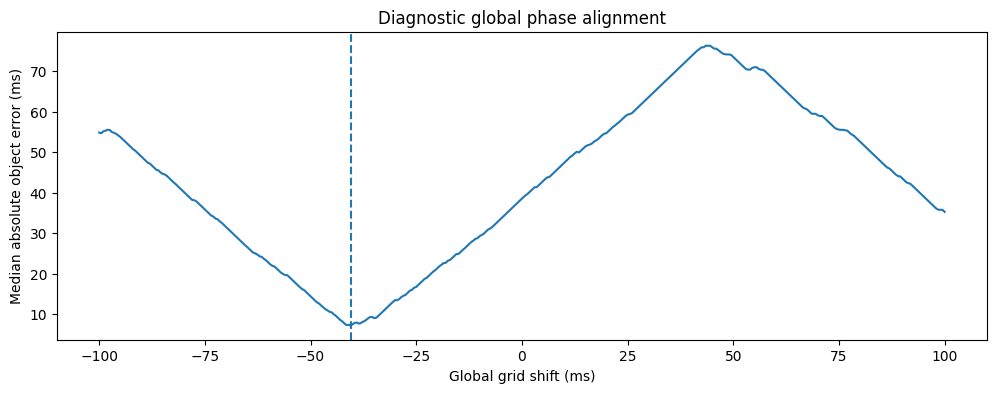

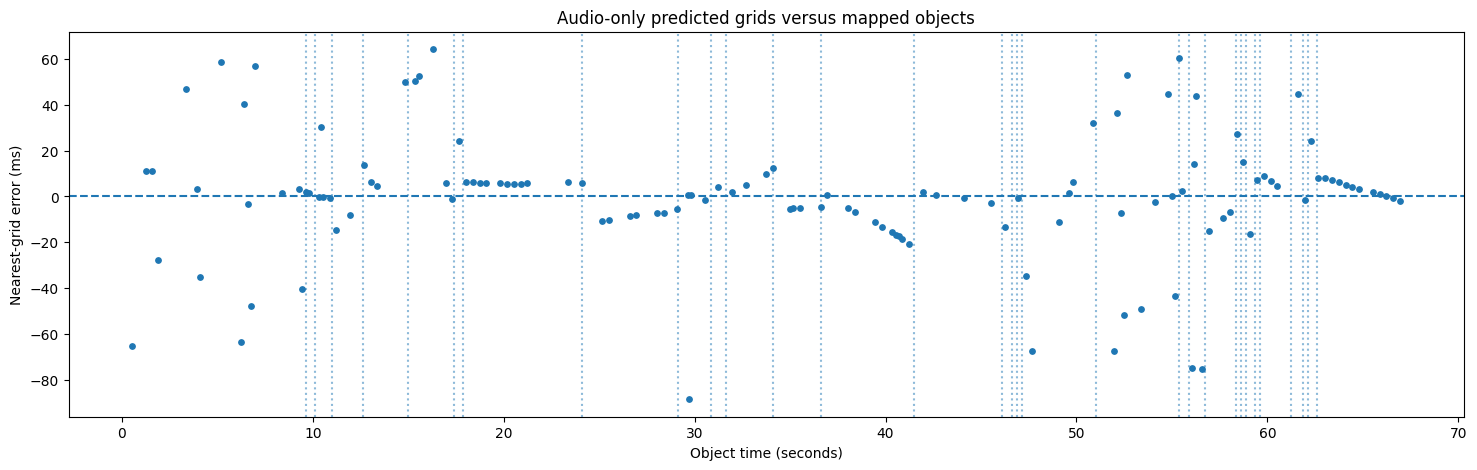

In [12]:
if evaluation is not None:
    plot_evaluation(evaluation)

## Per-section diagnostics

In [13]:
if evaluation is not None:
    print_section_diagnostics(evaluation)

Section  0 |   0.00–  9.62s |  67.400 BPM | n= 16 | median= 37.74 ms | p95= 63.95 ms | slope=  +0.85 ms/s | bad
Section  1 |   9.62– 10.12s |  83.500 BPM | n=  2 | median=  1.68 ms | p95=  1.97 ms | slope=  -3.58 ms/s | insufficient evidence
Section  2 |  10.12– 11.00s |  83.900 BPM | n=  4 | median=  0.47 ms | p95= 25.69 ms | slope= -21.19 ms/s | bad
Section  3 |  11.00– 12.00s |  84.700 BPM | n=  2 | median= 11.41 ms | p95= 14.39 ms | slope=  +9.26 ms/s | insufficient evidence
Section  4 |  12.62– 15.00s |  86.100 BPM | n=  4 | median=  9.89 ms | p95= 44.55 ms | slope= +20.18 ms/s | bad
Section  5 |  15.00– 17.38s |  82.400 BPM | n=  5 | median= 50.34 ms | p95= 61.78 ms | slope= -28.73 ms/s | bad
Section  6 |  17.38– 17.88s |  83.600 BPM | n=  1 | median= 24.06 ms | p95= 24.06 ms | slope=    n/a ms/s | insufficient evidence
Section  7 |  17.88– 24.12s |  84.000 BPM | n= 11 | median=  5.93 ms | p95=  6.29 ms | slope=  -0.03 ms/s | good
Section  8 |  24.12– 29.12s |  84.100 BPM | n=  7